In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess


def lowess_with_ci(x, y, frac=0.4, n_boot=200, ci=95, random_state=None):
    """LOWESS fit with bootstrap CI. Returns (y_smooth, y_lower, y_upper).
    Note: seaborn regplot ignores ci= when lowess=True, so we compute it manually.
    """
    rng = np.random.default_rng(random_state)
    n = len(x)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    result = lowess(y, x, frac=frac, return_sorted=True)
    y_smooth = np.interp(x, result[:, 0], result[:, 1])
    boot_preds = []
    for _ in range(n_boot):
        inds = rng.integers(0, n, size=n)
        try:
            res = lowess(y[inds], x[inds], frac=frac, return_sorted=True)
            boot_preds.append(np.interp(x, res[:, 0], res[:, 1]))
        except Exception:
            pass
    boot_preds = np.array(boot_preds)
    alpha = (100 - ci) / 2
    y_lower = np.percentile(boot_preds, alpha, axis=0)
    y_upper = np.percentile(boot_preds, 100 - alpha, axis=0)
    return y_smooth, y_lower, y_upper


In [29]:
# load wastewater metadata
metadata = pd.read_csv("../data/search_metadata.csv")

freyja_barcodes = pd.read_feather('../data/sars2_metadata/usher_barcodes.feather')
barcode_muts = freyja_barcodes.columns

# select non-coding regions
gff = pd.read_csv("../data/sars2_metadata/NC_045512_Hu-1.gff", sep="\t", header=None)
gff = gff[gff[2].str.contains("UTR", na=False) | gff[2].str.contains("stem_loop", na=False)]
intergenic_regions = []
for index, row in gff.iterrows():
    intergenic_regions.append((row[3], row[4]))

iontorrent_samples = metadata[metadata["collection_date"] < "2024-03-01"].sample(n=50, random_state=42)
illumina_samples = metadata[metadata["collection_date"] >= "2024-03-01"].sample(n=50, random_state=42)

snp_types = ["A>T", "A>C", "A>G", "T>A", "T>C", "T>G", "C>A", "C>T", "C>G", "G>A", "G>C", "G>T"]


def compute_snp_frequencies(variants_path, intergenic_regions):
    """Load variants, filter to intergenic SNVs, return SNP type frequencies."""
    try:
        variants = pd.read_csv(variants_path, sep="\t")
    except Exception:
        variants = pd.read_csv(variants_path.replace(".unfiltered", ""), sep="\t")
    variants = variants[variants["ALT"].str.len() == 1]
    mask = pd.Series(False, index=variants.index)
    for start, end in intergenic_regions:
        mask |= (variants["POS"] >= start) & (variants["POS"] <= end)
    variants = variants[mask]
    freqs = {st: 0 for st in snp_types}
    total = 0
    for _, row in variants.iterrows():
        if f'{row["REF"]}{row["POS"]}{row["ALT"]}' in barcode_muts:
            continue
        snp_type = f"{row['REF']}>{row['ALT']}"
        if snp_type in freqs:
            freqs[snp_type] += 1
            total += 1
    if total > 0:
        for k in freqs:
            freqs[k] /= total
    return freqs


iontorrent_freqs_list = []
illumina_freqs_list = []

for _, row in iontorrent_samples.iterrows():
    path = f"../data/original_bam/ivar/{row['sample']}.trimmed.sorted.unfiltered.tsv"
    f = compute_snp_frequencies(path, intergenic_regions)
    if sum(f.values()) > 0:
        iontorrent_freqs_list.append(f)

for _, row in illumina_samples.iterrows():
    path = f"../data/original_bam/ivar/{row['sample']}.trimmed.sorted.unfiltered.tsv"
    f = compute_snp_frequencies(path, intergenic_regions)
    current_max = 0
    max_sample = None
    if f["G>A"] > current_max:
        current_max = f["G>A"]
        max_sample = row["sample"]

print(max_sample, current_max)

# Print the illumina samples with the highest G>A frequency
for _, row in illumina_samples.iterrows():
    path = f"../data/original_bam/ivar/{row['sample']}.trimmed.sorted.unfiltered.tsv"
    f = compute_snp_frequencies(path, intergenic_regions)
    if sum(f.values()) > 0:
        illumina_freqs_list.append(f)

# Average SNP frequencies per platform (only samples with intergenic variants)
default_freqs = pd.Series({st: 0.0 for st in snp_types})
iontorrent_freqs = pd.DataFrame(iontorrent_freqs_list).mean() if iontorrent_freqs_list else default_freqs
illumina_freqs = pd.DataFrame(illumina_freqs_list).mean() if illumina_freqs_list else default_freqs


09_23_24_PLSEP18_R2__E0000000__X00__241003_SG_WW_2__001 0.15


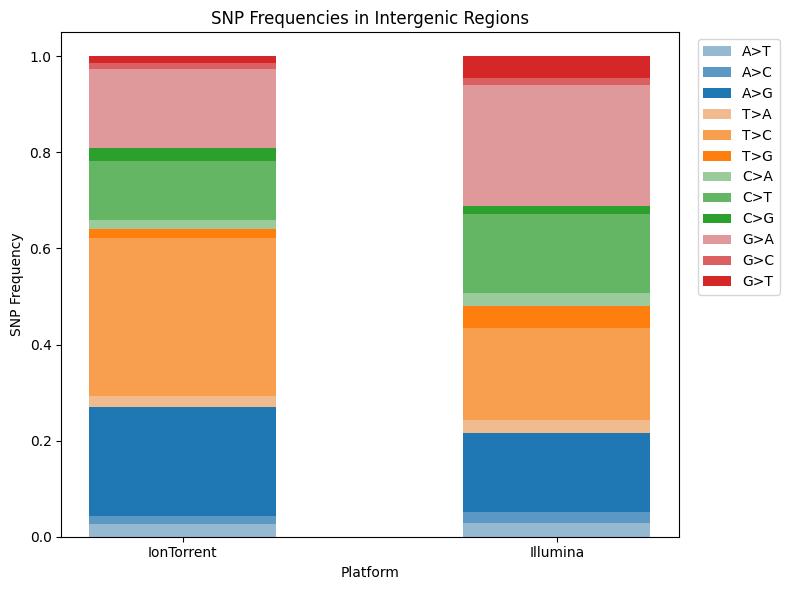

In [30]:
# plot snp frequencies as a stacked bar chart. compare illumina and iontorrent
snp_types = ["A>T", "A>C", "A>G", "T>A", "T>C", "T>G", "C>A", "C>T", "C>G", "G>A", "G>C", "G>T"]
# Different shades of same color per reference base (A=blue, T=orange, C=green, G=red)
base_colors = {"A": "#1f77b4", "T": "#ff7f0e", "C": "#2ca02c", "G": "#d62728"}
import matplotlib.colors as mcolors

def shades(base_hex, n=3):
    rgb = np.array(mcolors.to_rgb(base_hex))
    out = []
    for i in range(n):
        f = 0.4 + 0.6 * (i / (n - 1)) if n > 1 else 1
        blend = rgb * f + (1 - f) * 0.9
        out.append(mcolors.to_hex(np.clip(blend, 0, 1)))
    return out

ref_counts = {"A": 0, "T": 0, "C": 0, "G": 0}
colors = []
for st in snp_types:
    ref = st[0]
    s = shades(base_colors[ref])
    colors.append(s[ref_counts[ref] % 3])
    ref_counts[ref] += 1

fig, ax = plt.subplots(figsize=(8, 6))
x = [0, 1]
width = 0.5
bottom = np.zeros(2)

for i, snp_type in enumerate(snp_types):
    vals = np.array([iontorrent_freqs[snp_type], illumina_freqs[snp_type]])
    ax.bar(x, vals, width, bottom=bottom, label=snp_type, color=colors[i])
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(["IonTorrent", "Illumina"])
ax.set_xlabel("Platform")
ax.set_ylabel("SNP Frequency")
ax.set_title("SNP Frequencies in Intergenic Regions")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)
plt.tight_layout()

plt.show()

In [31]:
nuc_to_idx = {"A": 0, "T": 1, "C": 2, "G": 3}


def build_error_matrix(freqs):
    matrix = np.zeros((4, 4))
    for snp_type, value in freqs.items():
        ref, alt = snp_type[0], snp_type[2]
        matrix[nuc_to_idx[alt], nuc_to_idx[ref]] = value
    for i in range(4):
        matrix[i, i] = 1 - matrix[i, :].sum()
    return matrix 


iontorrent_matrix = build_error_matrix(iontorrent_freqs)
illumina_matrix = build_error_matrix(illumina_freqs)

print("IonTorrent error matrix:")
print(iontorrent_matrix)
print("\nIllumina error matrix:")
print(illumina_matrix)

np.save("iontorrent_error_matrix.npy", iontorrent_matrix)
np.save("illumina_error_matrix.npy", illumina_matrix)


IonTorrent error matrix:
[[0.79442216 0.02272335 0.01830393 0.16455057]
 [0.02617711 0.83597425 0.12447926 0.01336939]
 [0.01658567 0.32895201 0.64124442 0.0132179 ]
 [0.22730344 0.01842809 0.02590929 0.72835917]]

Illumina error matrix:
[[0.69232985 0.0279613  0.02775178 0.25195707]
 [0.02919045 0.76023554 0.16540846 0.04516555]
 [0.02158497 0.19051592 0.77420311 0.013696  ]
 [0.16506785 0.04501067 0.01668998 0.7732315 ]]


/tmp/ipykernel_2975994/1486399601.py:51: RuntimeWarning: invalid value encountered in divide
  true_vec = true_vec / true_vec.sum()
/tmp/ipykernel_2975994/1486399601.py:51: RuntimeWarning: invalid value encountered in divide
  true_vec = true_vec / true_vec.sum()
/tmp/ipykernel_2975994/1486399601.py:51: RuntimeWarning: invalid value encountered in divide
  true_vec = true_vec / true_vec.sum()
/tmp/ipykernel_2975994/1486399601.py:51: RuntimeWarning: invalid value encountered in divide
  true_vec = true_vec / true_vec.sum()
/tmp/ipykernel_2975994/1486399601.py:51: RuntimeWarning: invalid value encountered in divide
  true_vec = true_vec / true_vec.sum()
/tmp/ipykernel_2975994/1486399601.py:51: RuntimeWarning: invalid value encountered in divide
  true_vec = true_vec / true_vec.sum()
/tmp/ipykernel_2975994/1486399601.py:51: RuntimeWarning: invalid value encountered in divide
  true_vec = true_vec / true_vec.sum()
/tmp/ipykernel_2975994/1486399601.py:51: RuntimeWarning: invalid value encou

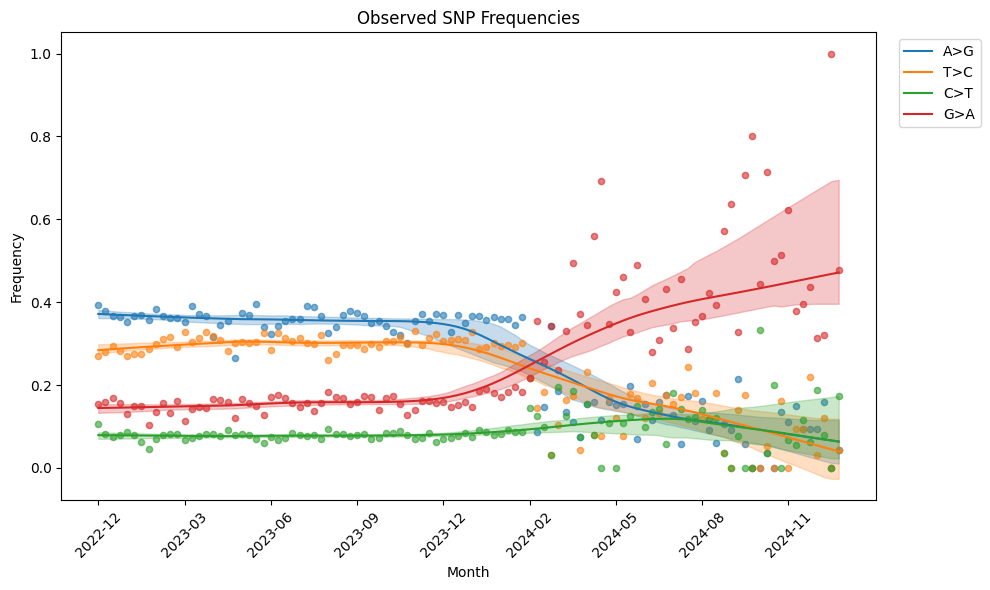

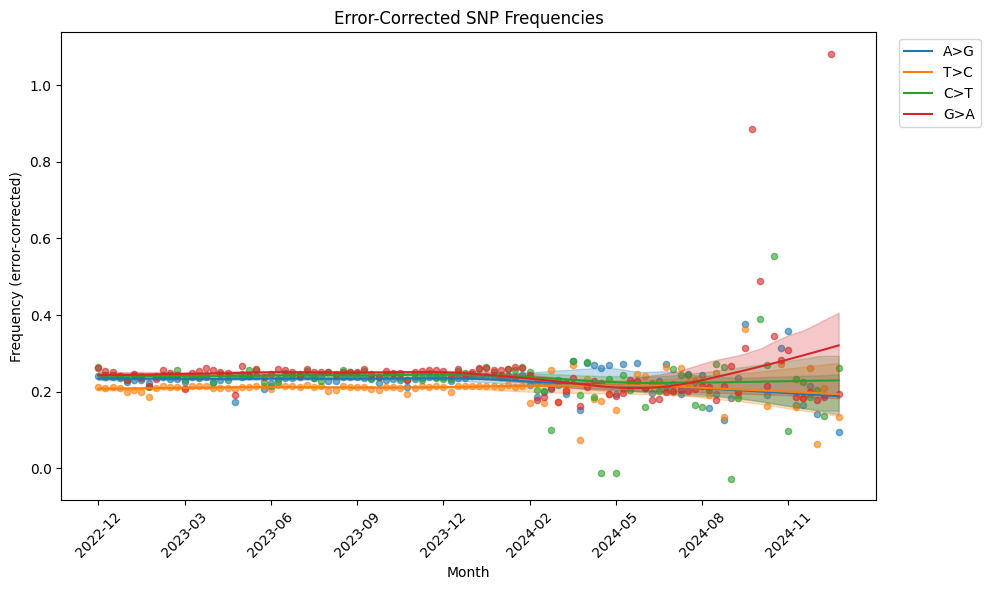

In [32]:
nucs = ["A", "T", "C", "G"]
snp_types = ["A>G", "T>C", "C>T", "G>A"]
#snp_types = ["A>T", "A>C", "A>G", "T>A", "T>C", "T>G", "C>A", "C>T", "C>G", "G>A", "G>C", "G>T"]

cutoff_date = pd.to_datetime("2024-03-01")

# load cryptic snp frequencies
obs_counts = pd.read_csv("../snp_frequencies/cryptic_snp_freqs.csv").set_index("week")
#obs_counts = pd.read_csv("../snp_frequencies/non_cryptic_snp_freqs.csv").set_index("week")
obs_counts.index = pd.to_datetime(obs_counts.index)

obs_freq = obs_counts.div(obs_counts.sum(axis=1), axis=0)
# Plot observed frequencies: points + LOESS
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(obs_freq))
plot_colors = {"A>G": "#1f77b4", "T>C": "#ff7f0e", "C>T": "#2ca02c", "G>A": "#d62728"}
for col in snp_types:
    if col in obs_freq.columns:
        y_vals = obs_freq[col].values
        y_smooth, y_lo, y_hi = lowess_with_ci(x, y_vals, frac=0.4, n_boot=200, ci=95)
        c = plot_colors.get(col)
        ax.fill_between(x, y_lo, y_hi, alpha=0.25, color=c)
        ax.plot(x, y_smooth, color=c, label=col)
        ax.scatter(x, y_vals, color=c, alpha=0.6, s=20)
ax.set_xticks(x[::12])
ax.set_xticklabels(obs_freq.index[::12].strftime("%Y-%m"), rotation=45)
ax.set_xlabel("Month")
ax.set_ylabel("Frequency")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)
ax.set_title("Observed SNP Frequencies")
plt.tight_layout()


# error correction
true_counts = obs_counts.copy().astype(float)
true_counts.loc[:, :] = 0

for period in obs_counts.index:
    if period < cutoff_date:
        error_matrix_base = iontorrent_matrix.copy()
    else:
        error_matrix_base = illumina_matrix.copy()

    for ref_nuc in nucs:
        alts = [n for n in nucs if n != ref_nuc]
        obs_vec = np.array([obs_counts.loc[period, f"{ref_nuc}>{alt}"] for alt in alts])
 
        reduced_matrix = np.delete(error_matrix_base, nucs.index(ref_nuc), axis=0)
        true_vec = np.linalg.pinv(reduced_matrix) @ obs_vec

        true_vec = true_vec / true_vec.sum()

        true_counts.loc[period, f"{ref_nuc}>{ref_nuc}"] = true_vec[nucs.index(ref_nuc)]
        for alt_nuc in alts:
            true_counts.loc[period, f"{ref_nuc}>{alt_nuc}"] = true_vec[nucs.index(alt_nuc)]


# convert true_counts to frequencies (normalize over 12 SNP types only, same as obs_freq)
true_freq = true_counts[obs_counts.columns].div(true_counts[obs_counts.columns].sum(axis=1), axis=0)
# Plot error-corrected: points + LOESS
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(true_freq))
for col in snp_types:
    if col in true_freq.columns:
        y_vals = true_freq[col].values
        y_smooth, y_lo, y_hi = lowess_with_ci(x, y_vals, frac=0.4, n_boot=200, ci=95)
        c = plot_colors.get(col)
        ax.fill_between(x, y_lo, y_hi, alpha=0.25, color=c)
        ax.plot(x, y_smooth, color=c, label=col)
        ax.scatter(x, y_vals, color=c, alpha=0.6, s=20)
ax.set_xticks(x[::12])
ax.set_xticklabels(true_freq.index[::12].strftime("%Y-%m"), rotation=45)
ax.set_xlabel("Month")
ax.set_ylabel("Frequency (error-corrected)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)
ax.set_title("Error-Corrected SNP Frequencies")
plt.tight_layout()
plt.show()